<a href="https://colab.research.google.com/github/vitorjensen/Martech/blob/main/Data%20Science%20para%20Marketing/Analisando%20e%20Explorando%20Dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Anotações Aula 1 - Conhecendo os Dados

In [ ]:
nome_influenciador = "Vitor"
print(nome_influenciador)

Vitor


####Importando bibliotecas padrão

In [ ]:
import pandas as pd
import seaborn as sns

####Criando um dataframe para ser lido o CSV de dados

In [ ]:
campanha = pd.read_csv("/content/campanha.csv")

#### Usando comando Shape para mostrar as dimensões da tabela

In [ ]:
campanha.shape

(50000, 8)

####Usando função head() para exibir apenas as 5 linhas iniciais do dataframe

In [ ]:
campanha.head()

,Id_campanha,impressoes,cliques,canal,custo,receita,estado,pais
0,1,152431,9462,Email,13258,32309,MG,Brasil
1,1,39688,3218,PPC,16391,16568,BA,Brasil
2,1,104506,4756,Google Ads,6189,19029,AL,Brasil
3,1,80768,3566,Google Ads,5215,0,PI,Brasil
4,1,54932,3645,Google Ads,16767,8825,RJ,Brasil


####Filtrando o dataframe apenas pela coluna "canal"

In [ ]:
campanha['canal']

,canal
0,Email
1,PPC
2,Google Ads
3,Google Ads
4,Google Ads
...,...
49995,Social Media
49996,Google Ads
49997,Google Ads
49998,PPC


####Usando função unique() para poder exibir valores únicos do campo 'canal'

In [ ]:
campanha['canal'].unique()

array(['Email', 'PPC', 'Google Ads', 'Meta Ads', 'Social Media'],
      dtype=object)

####Usando a função value_counts() na coluna 'cana' para poder contar os números por canal

In [ ]:
campanha['canal'].value_counts()

,count
canal,
Google Ads,25146
Meta Ads,15009
Social Media,4874
PPC,2526
Email,2445


####Criando novo campo para calcular a Métrica CTR (Click-Through Rate ou Taxa de Cliques), cliques/impressões

In [ ]:
campanha['ctr']=(campanha['cliques']/campanha['impressoes'])*100
campanha.head()

,Id_campanha,impressoes,cliques,canal,custo,receita,estado,pais,ctr
0,1,152431,9462,Email,13258,32309,MG,Brasil,6.207399
1,1,39688,3218,PPC,16391,16568,BA,Brasil,8.108244
2,1,104506,4756,Google Ads,6189,19029,AL,Brasil,4.550935
3,1,80768,3566,Google Ads,5215,0,PI,Brasil,4.415115
4,1,54932,3645,Google Ads,16767,8825,RJ,Brasil,6.635477


####Após a criação da coluna 'ctr', utilizamos o describe() para mostrar um panorama das "Medidas De Tendências Centrais" (Media, Moda e Mediana) e "Medida de Dispersão" (Desvio Padrão).

In [ ]:
campanha["ctr"].describe()

,ctr
count,50000.000000
mean,5.148482
std,1.604119
min,0.992663
25%,4.050781
50%,5.132384
75%,6.241502
max,10.000000


####Utilizando o SeaBorn para exibir os dados do CTR em um boxplot

<Axes: ylabel='ctr'>

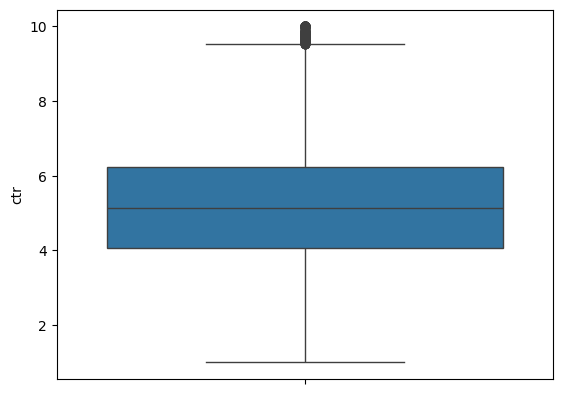

In [ ]:
sns.boxplot(campanha["ctr"])

##Anotações Aula 2 - Analisando os Dados:

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#### Usando Query

In [ ]:
campanha = pd.read_csv("/content/campanha.csv")

#### Filtrando campanhas com ID 1 apenas. Passar parâmetro "numeric_only=true"

In [ ]:
campanha.query('Id_campanha == 1').mean(numeric_only=True)

,0
Id_campanha,1.000000
impressoes,96580.806452
cliques,4902.096774
custo,13863.419355
receita,14000.806452


####Filtrando campanhas com ID 1 apenas + o campo de impressões e tirando a média

In [ ]:
campanha.query('Id_campanha == 1')['impressoes'].mean()

np.float64(96580.80645161291)

####Fazendo uma análise segmentada utilizando o GROUPBY e guardando a query numa variável

In [ ]:
medias_por_campanha = campanha.groupby('Id_campanha')['impressoes'].mean()
medias_por_campanha.head()

,impressoes
Id_campanha,
1,96580.806452
2,92372.923077
3,118489.333333
4,96947.681818
5,105508.291667


#### Exibindo o groupby utilizando um histograma

<Axes: ylabel='Frequency'>

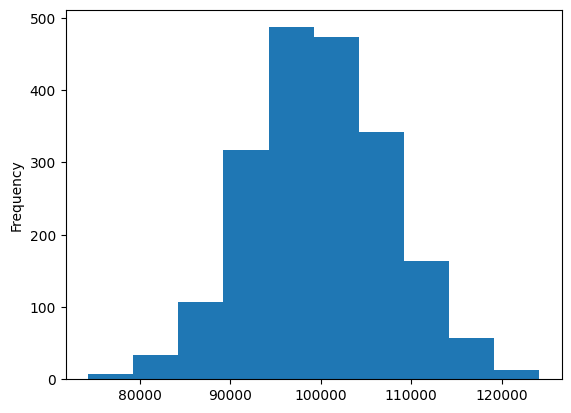

In [ ]:
medias_por_campanha.plot(kind='hist')

#### Utilizando o GROUPBY para fazer uma analise segmentada agora usando os campos "canal" e "ctr"

In [ ]:
campanha['ctr']=(campanha['cliques']/campanha['impressoes'])*100

In [ ]:
metricas_por_tipo = campanha.groupby('canal')['ctr'].mean()
metricas_por_tipo.head()

,ctr
canal,
Email,5.109386
Google Ads,5.152163
Meta Ads,5.133841
PPC,5.162208
Social Media,5.187068


####Utilizando o Displot (Seaborn) e Marplotlib para visualizar as informações. Uso do Discribe

In [ ]:
medias_por_campanha.describe()

,impressoes
count,2000.000000
mean,99924.847399
std,7651.690148
min,74315.388889
25%,94601.752717
50%,99731.860577
75%,105173.546176
max,124154.071429


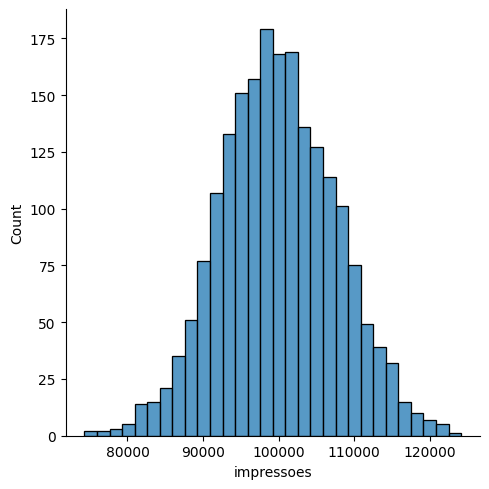

In [ ]:
sns.displot(medias_por_campanha)

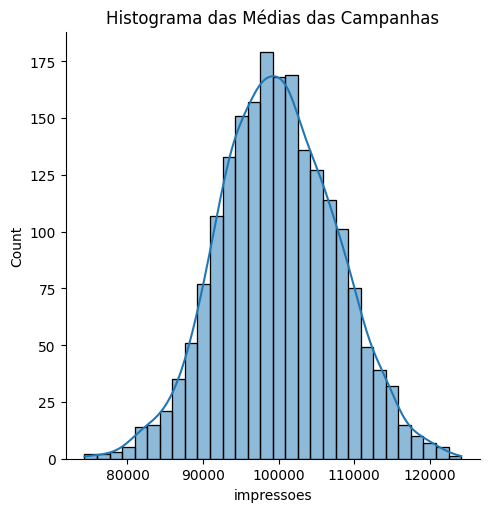

In [ ]:
sns.displot(medias_por_campanha, kde = True)
plt.title('Histograma das Médias das Campanhas')
plt.show()

####Continuação das anotações da Aula 2 18/06/2026

####Adicionando novamente as bibliotecas e importando a base

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
dados = pd.read_csv('/content/vendas_zoop.csv')

####Visualizando dados

In [ ]:
dados

,ID_venda,Data,Horario,Canal_venda,Origem_venda,ID_produto,Produto,Categoria_produto,Preco_unitario,Quantidade,Metodo_pagamento,ID_cliente,Nome_cliente,Genero_cliente,Idade_cliente,Cidade_cliente,UF_cliente,Regiao_cliente,Avaliacao
0,0,2021-08-20,08:58:00,Loja 2,Loja,3,Cafeteira,Eletrodomésticos,199.0,3,Cartão de débito,21,Manuella Pereira,Feminino,28,Campo Grande,Mato Grosso do Sul,Centro-Oeste,4
1,1,2021-08-20,11:32:00,Loja 1,Loja,14,Impressora,Eletrônicos,599.0,1,Dinheiro,218,Maria Sophia Rios,Feminino,40,Uberlândia,Minas Gerais,Sudeste,3
2,2,2021-08-20,13:19:00,Loja 1,Loja,29,Máquina de café,Eletrodomésticos,599.0,2,Cartão de crédito,277,Ana Sophia Marques,Feminino,34,Campinas,São Paulo,Sudeste,5
3,3,2021-08-20,13:42:00,Loja 2,Loja,3,Cafeteira,Eletrodomésticos,199.0,1,PIX,282,Clara Rezende,Feminino,39,São Gonçalo,Rio de Janeiro,Sudeste,3
4,4,2021-08-20,14:49:00,Loja 1,Loja,8,Micro-ondas,Eletrodomésticos,499.0,1,Cartão de débito,295,Thiago Lima,Masculino,59,Foz do Iguaçu,Paraná,Sul,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,2024-08-19,03:36:16,e-commerce,Facebook,24,TV Box,Eletrônicos,299.0,2,Cartão de crédito,207,Leandro Fonseca,Masculino,38,São Bernardo do Campo,São Paulo,Sudeste,5
9996,9996,2024-08-19,13:51:58,e-commerce,Facebook,27,Câmera de segurança,Eletrônicos,399.0,2,Cartão de crédito,408,Otávio Souza,Masculino,35,Fortaleza,Ceará,Nordeste,2
9997,9997,2024-08-19,15:37:49,e-commerce,Facebook,2,Ventilador de teto,Eletrodomésticos,249.0,3,Cartão de débito,434,Manuela Cirino,Feminino,34,Salvador,Bahia,Nordeste,5
9998,9998,2024-08-19,18:39:55,e-commerce,Facebook,22,Geladeira,Eletrodomésticos,2799.0,2,PIX,432,Larissa Melo,Feminino,45,São Paulo,São Paulo,Sudeste,5


####Criando um Boxplot para visualizar a distribuição

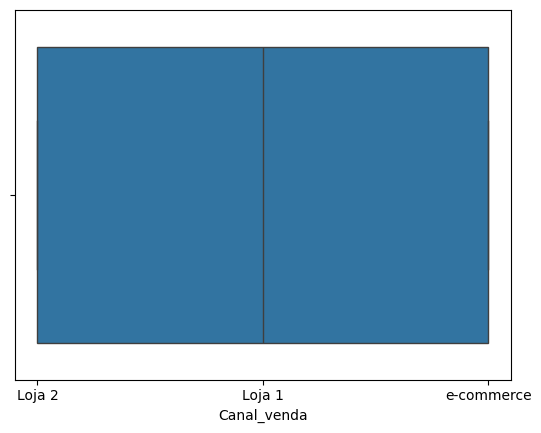

In [ ]:
sns.boxplot(x=dados['Canal_venda'])
plt.show()

####Analisando as estatísticas descritivas usando o describe

In [ ]:
dados['Canal_venda'].describe()

,Canal_venda
count,10000
unique,3
top,e-commerce
freq,3381


####Criando um histograma mais detalhado usando a função displot

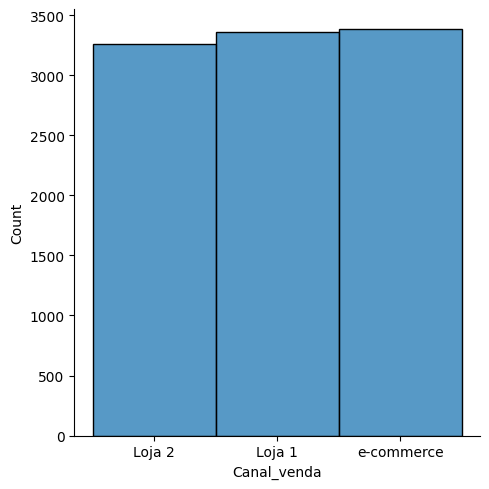

In [ ]:
sns.displot(x=dados['Canal_venda'])
plt.show()

####Criando um histrograma com o argumento 'kde' para visualizar a curva de densidade

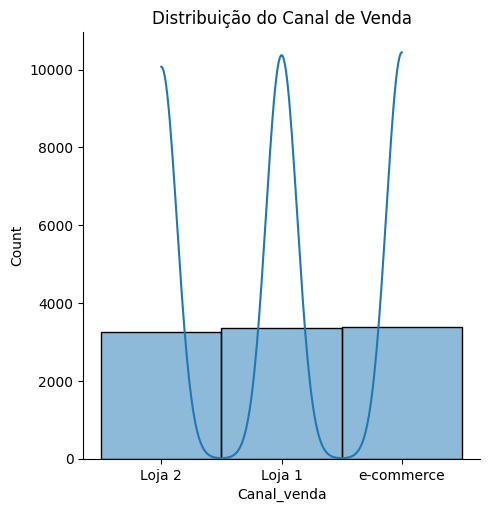

In [ ]:
sns.displot(x=dados['Canal_venda'], kde=True)
plt.title('Distribuição do Canal de Venda')
plt.show()

####Analisando usando o 'displot' a relação entre a coluna: Categoria do Produto pela região do cliente.

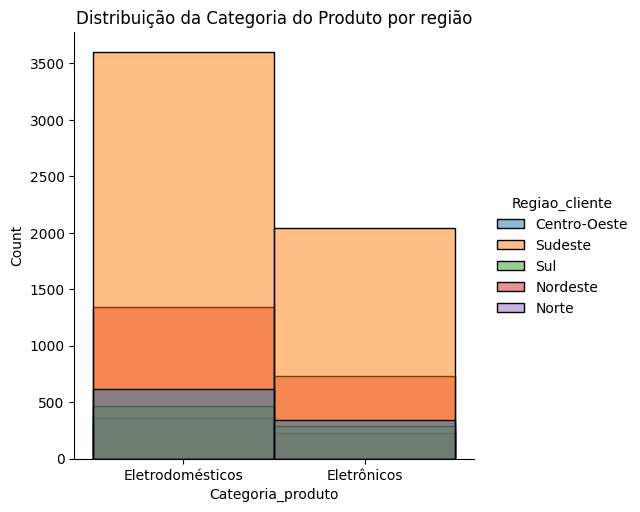

In [ ]:
sns.displot(x=dados['Categoria_produto'], hue=dados['Regiao_cliente'])
plt.title('Distribuição da Categoria do Produto por região')
plt.show()

####Analisando usando o 'displot' a relação entre a coluna: Categoria do Produto pelo Gênero.

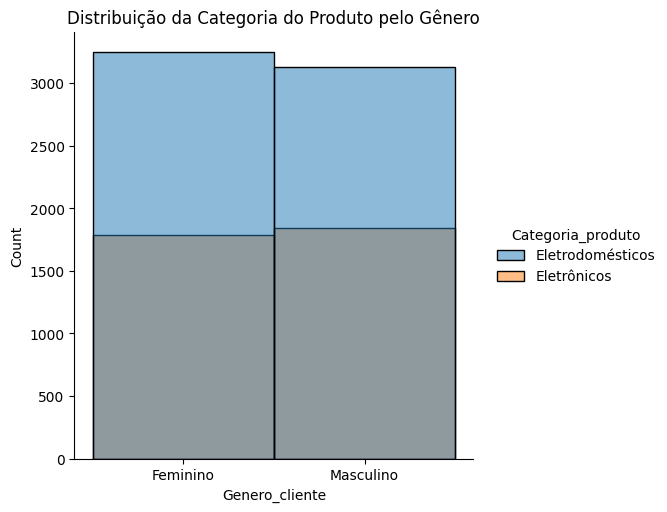

In [ ]:
sns.displot(x=dados['Genero_cliente'], hue=dados['Categoria_produto'])
plt.title('Distribuição da Categoria do Produto pelo Gênero')
plt.show()

##Anotações Aula 3 - Entendendo os tipos de variáveis:

#### Analisando a performance de campanhas de marketing

####Analisando o comportamento da Receita e do Custo (Importante)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
campanhas = pd.read_csv('/content/campanha.csv')

####Analisando o comportamento da Receita

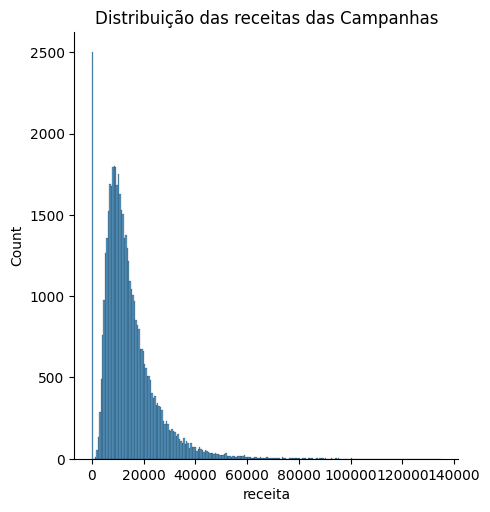

In [ ]:
sns.displot(campanhas['receita'])
plt.title('Distribuição das receitas das Campanhas')
plt.show()

####Analisando o comportamento do Custo:

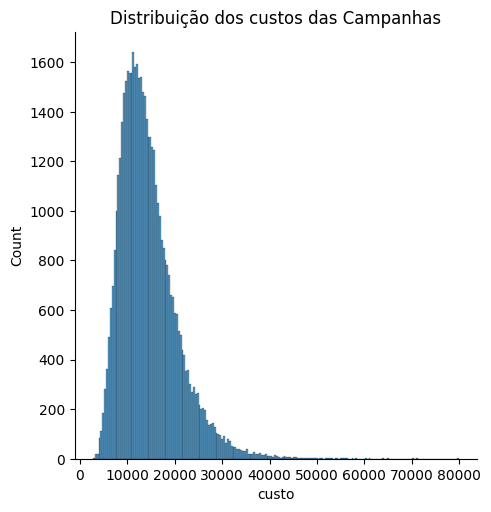

In [ ]:
sns.displot(campanhas['custo'])
plt.title('Distribuição dos custos das Campanhas')
plt.show()

####Descobrindo o tipo de dados usados na tabela

In [ ]:
campanhas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Id_campanha  50000 non-null  int64 
 1   impressoes   50000 non-null  int64 
 2   cliques      50000 non-null  int64 
 3   canal        50000 non-null  object
 4   custo        50000 non-null  int64 
 5   receita      50000 non-null  int64 
 6   estado       50000 non-null  object
 7   pais         50000 non-null  object
dtypes: int64(5), object(3)
memory usage: 3.1+ MB


####Trabalhando com tipos de variáveis

In [ ]:
campanhas['estado']

,estado
0,MG
1,BA
2,AL
3,PI
4,RJ
...,...
49995,MG
49996,MA
49997,RS
49998,DF


In [ ]:
campanhas['estado'].unique()

array(['MG', 'BA', 'AL', 'PI', 'RJ', 'SP', 'MA', 'PE', 'MS', 'DF', 'CE',
       'AM', 'SE', 'PA', 'PR', 'SC', 'GO', 'RN', 'RO', 'ES', 'MT', 'TO',
       'PB', 'RS', 'AC', 'AP', 'RR'], dtype=object)

In [ ]:
campanhas['estado'].value_counts()

,count
estado,
SP,11006
MG,4902
RJ,4221
BA,3524
RS,2701
PR,2698
PE,2255
CE,2140
PA,2024


##Anotações da Aula 4 - Visualizando os dados

#### Explorando gráficos com variáveis categóricas

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
campanha = pd.read_csv('/content/campanha.csv')

####Utilizando o unique no campo "estado" para visualizar única ocorrência

In [4]:
campanha['estado'].unique()

array(['MG', 'BA', 'AL', 'PI', 'RJ', 'SP', 'MA', 'PE', 'MS', 'DF', 'CE',
       'AM', 'SE', 'PA', 'PR', 'SC', 'GO', 'RN', 'RO', 'ES', 'MT', 'TO',
       'PB', 'RS', 'AC', 'AP', 'RR'], dtype=object)

####Realizando uma contagem total por estado

In [5]:
campanha['estado'].value_counts()

,count
estado,
SP,11006
MG,4902
RJ,4221
BA,3524
RS,2701
PR,2698
PE,2255
CE,2140
PA,2024


####Mostrando que a coluna "estado" está funcionando como **indice** e a coluna count como **values** (valores)

In [6]:
campanha['estado'].value_counts().index

Index(['SP', 'MG', 'RJ', 'BA', 'RS', 'PR', 'PE', 'CE', 'PA', 'SC', 'GO', 'MA',
       'AM', 'PB', 'ES', 'MT', 'RN', 'PI', 'AL', 'DF', 'MS', 'SE', 'RO', 'TO',
       'AC', 'AP', 'RR'],
      dtype='object', name='estado')

In [7]:
campanha['estado'].value_counts().values

array([11006,  4902,  4221,  3524,  2701,  2698,  2255,  2140,  2024,
        1741,  1715,  1643,   959,   952,   927,   839,   823,   784,
         784,   714,   674,   586,   445,   345,   226,   217,   155])

####Transformando value_counts() em um dataframe

In [8]:
campanha['estado'].value_counts().to_frame()

,count
estado,
SP,11006
MG,4902
RJ,4221
BA,3524
RS,2701
PR,2698
PE,2255
CE,2140
PA,2024


####Criando uma nova coluna para ser o índice

In [9]:
campanha['estado'].value_counts().to_frame().reset_index()

,estado,count
0,SP,11006
1,MG,4902
2,RJ,4221
3,BA,3524
4,RS,2701
5,PR,2698
6,PE,2255
7,CE,2140
8,PA,2024
9,SC,1741


####Manipulando as colunas para poder editar os nomes

In [10]:
count_column = campanha['estado'].value_counts().to_frame().reset_index()
count_column.columns =  ['estado', 'total']
count_column

,estado,total
0,SP,11006
1,MG,4902
2,RJ,4221
3,BA,3524
4,RS,2701
5,PR,2698
6,PE,2255
7,CE,2140
8,PA,2024
9,SC,1741


#### Utilizando comando plot para visualizar o dataframe

<Axes: >

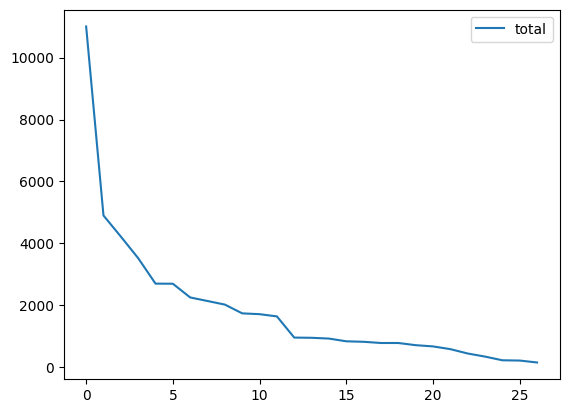

In [11]:
count_column.plot()

#### Agora utilizando o gráfico ideal o de barras, para visualizar corretamente os dados

<Axes: xlabel='estado', ylabel='total'>

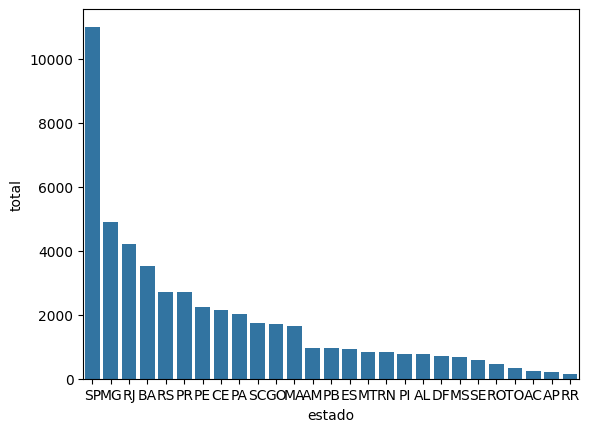

In [ ]:
sns.barplot(data=count_column, x='estado', y='total')

####Usando nova função: countplot do seaborn para facilitar a contagem de valores diretamente no gráfico

<Axes: xlabel='estado', ylabel='count'>

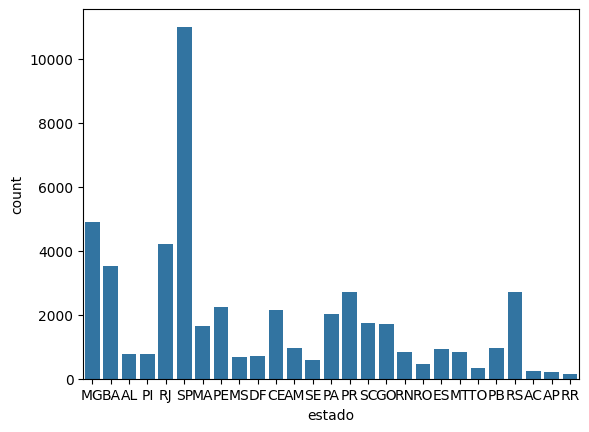

In [ ]:
sns.countplot(data=campanha, x='estado')

####Trabalhando com o Gráfico de Setores (Pizza)

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

####Utilizando o gráfico de setores para visualizar a distribuição de estados

<Axes: ylabel='total'>

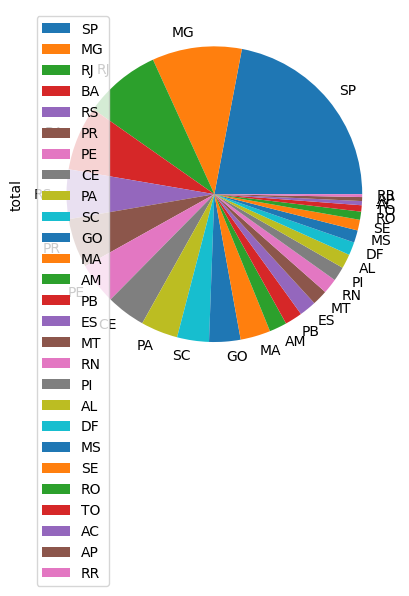

In [14]:
count_column.plot(y='total', kind='pie', labels=count_column['estado'])

####Manipulando o gráfico

####Criando um dicionário

In [18]:
total_por_estado = campanha['estado'].value_counts()
total_geral = total_por_estado.sum()
total_em_sp = total_por_estado.loc['SP']
total_do_restante = total_geral - total_em_sp
print(total_geral, total_em_sp, total_do_restante)

50000 11006 38994


In [19]:
dados = {
    'estado' : ['SP', 'outros'],
    'total' : [total_em_sp, total_do_restante]
}
dados = pd.DataFrame(dados)
dados.head()

,estado,total
0,SP,11006
1,outros,38994


<Axes: ylabel='total'>

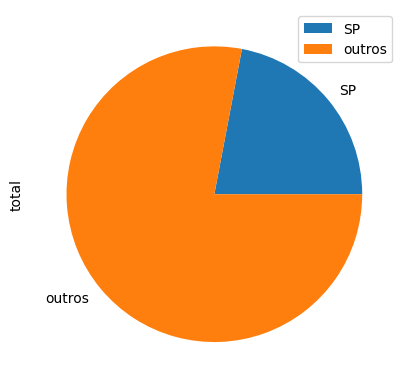

In [21]:
dados.plot(kind='pie', y='total', labels=dados['estado'])